In [1]:
!pip install tetgen pyvista -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 411.1/411.1 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.4/229.4 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.0/146.0 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 20.2 MB/s eta 0:00:00


In [2]:
import tetgen
import pyvista as pv
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


Nodes: (1098, 3)
Elements: (4937, 4)


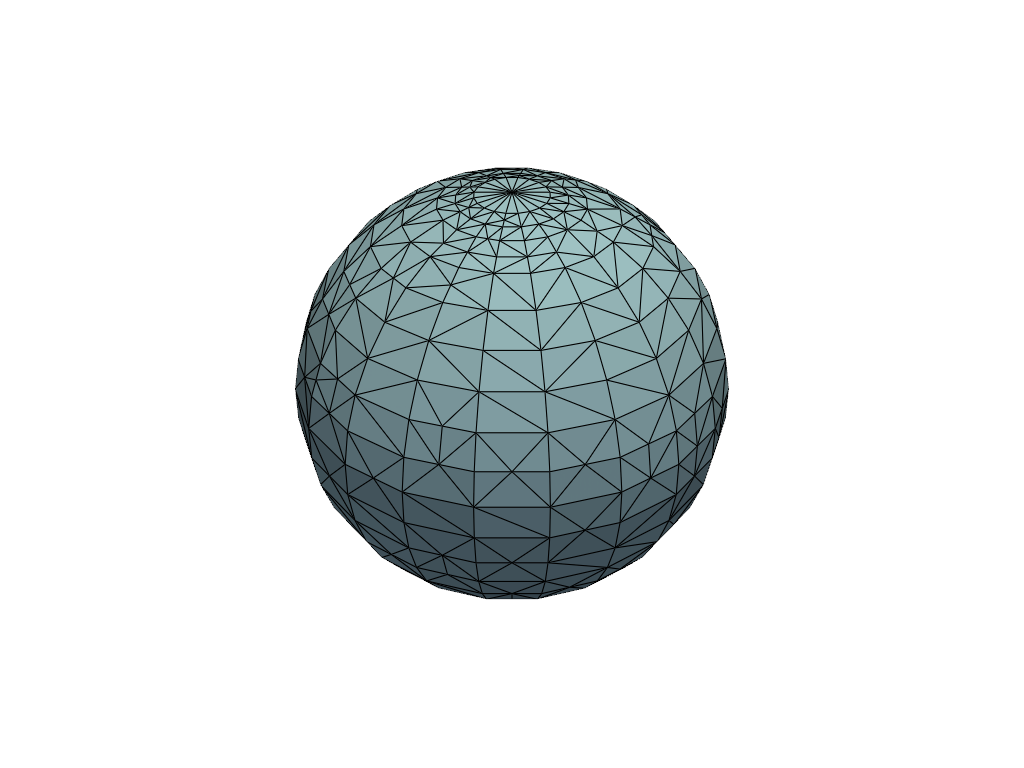

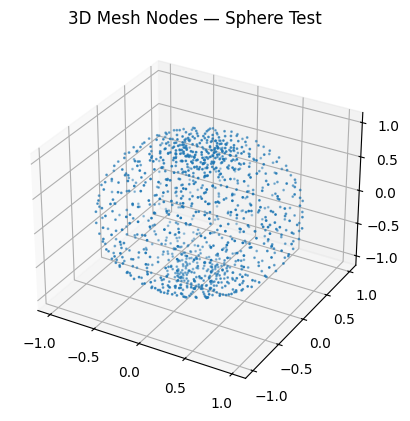

In [3]:
# SECTION 2 — Quick Sphere Test
mesh = pv.Sphere(radius=1.0, theta_resolution=20, phi_resolution=20)

tet  = tetgen.TetGen(mesh)
tet.tetrahedralize(order=1, mindihedral=20, minratio=1.5)
grid  = tet.grid
nodes = grid.points
elements = grid.cells.reshape(-1, 5)[:, 1:]

print("Nodes:", nodes.shape)
print("Elements:", elements.shape)

pv.set_jupyter_backend('static')
plotter = pv.Plotter(notebook=True)
plotter.add_mesh(grid, show_edges=True)
plotter.show()

fig = plt.figure()
ax  = fig.add_subplot(projection='3d')
ax.scatter(nodes[:,0], nodes[:,1], nodes[:,2], s=1)
plt.title("3D Mesh Nodes — Sphere Test")
plt.show()

In [4]:
GEOMETRY_LABEL = {
    'sphere'  : 0,
    'cylinder': 1,
    'torus'   : 2,
}

# Lower minratio → denser mesh (more nodes)
# Higher minratio → coarser mesh (fewer nodes)
MINRATIOS = [1.3, 1.5, 1.8, 2.0, 2.5] # Reduced to 5 values

# New: Resolution configurations for each geometry
RESOLUTION_CONFIGS = {
    'sphere': [
        {'theta_resolution': 20, 'phi_resolution': 20},
        {'theta_resolution': 25, 'phi_resolution': 25},
        {'theta_resolution': 30, 'phi_resolution': 30},
    ],
    'cylinder': [
        {'resolution': 30},
        {'resolution': 40},
    ],
    'torus': [
        {'u_res': 20, 'v_res': 20, 'w_res': 20},
        {'u_res': 25, 'v_res': 25, 'w_res': 25},
    ],
}

def make_sphere(theta_resolution=20, phi_resolution=20):
    return pv.Sphere(radius=1.0,
                     theta_resolution=theta_resolution,
                     phi_resolution=phi_resolution)

def make_cylinder(resolution=30):
    cyl = pv.Cylinder(radius=0.5, height=1.0, resolution=resolution)
    cyl = cyl.triangulate()
    cyl = cyl.subdivide(1)
    cyl = cyl.clean()
    return cyl

def make_torus(u_res=20, v_res=20, w_res=20):
    tor = pv.ParametricTorus(
        ringradius=1.0,
        crosssectionradius=0.3,
        u_res=u_res,
        v_res=v_res,
        w_res=w_res
    )
    return tor.triangulate()

GEOMETRY_BUILDERS = {
    'sphere'  : make_sphere,
    'cylinder': make_cylinder,
    'torus'   : make_torus,
}

# Main generation loop
raw_dataset = []

for geo_name, label in GEOMETRY_LABEL.items():
    print(f"\nGeometry: {geo_name} (label={label})")

    # Iterate through different resolutions for the current geometry
    for res_config in RESOLUTION_CONFIGS[geo_name]:
        # Iterate through different minratios
        for minratio in MINRATIOS:
            try:
                # Pass resolution parameters to the builder function
                surface = GEOMETRY_BUILDERS[geo_name](**res_config)
                tet     = tetgen.TetGen(surface)
                tet.tetrahedralize(order=1, mindihedral=20, minratio=minratio)
                grid    = tet.grid
                nodes   = grid.points.copy()

                raw_dataset.append({
                    'nodes'   : nodes,
                    'label'   : label,
                    'geometry': geo_name,
                    'minratio': minratio,
                    'resolution_config': res_config, # Store resolution config
                    'n_nodes' : len(nodes),
                })

                res_str = ", ".join(f"{k}={v}" for k, v in res_config.items())
                print(f"  res=[{res_str}], minratio={minratio:.1f} → {len(nodes):5d} nodes")

            except Exception as e:
                res_str = ", ".join(f"{k}={v}" for k, v in res_config.items())
                print(f"  res=[{res_str}], minratio={minratio:.1f} → FAILED: {e}")

print(f"\nTotal samples collected: {len(raw_dataset)}")

# Node count summary
all_n = [d['n_nodes'] for d in raw_dataset]
print(f"Min nodes : {min(all_n)}")
print(f"Max nodes : {max(all_n)}")
print(f"Mean nodes: {int(np.mean(all_n))}")


Geometry: sphere (label=0)
  res=[theta_resolution=20, phi_resolution=20], minratio=1.3 →  1048 nodes
  res=[theta_resolution=20, phi_resolution=20], minratio=1.5 →  1098 nodes
  res=[theta_resolution=20, phi_resolution=20], minratio=1.8 →  1158 nodes
  res=[theta_resolution=20, phi_resolution=20], minratio=2.0 →  1170 nodes
  res=[theta_resolution=20, phi_resolution=20], minratio=2.5 →  1387 nodes
  res=[theta_resolution=25, phi_resolution=25], minratio=1.3 →  1584 nodes
  res=[theta_resolution=25, phi_resolution=25], minratio=1.5 →  1582 nodes
  res=[theta_resolution=25, phi_resolution=25], minratio=1.8 →  2121 nodes
  res=[theta_resolution=25, phi_resolution=25], minratio=2.0 →  2239 nodes
  res=[theta_resolution=25, phi_resolution=25], minratio=2.5 →  2606 nodes
  res=[theta_resolution=30, phi_resolution=30], minratio=1.3 →  2485 nodes
  res=[theta_resolution=30, phi_resolution=30], minratio=1.5 →  2789 nodes
  res=[theta_resolution=30, phi_resolution=30], minratio=1.8 →  3564 nod

Processed 35 samples
Matrix shape : (3, 32, 64)
Mask shape   : (1, 32, 64)

DataLoader ready
  Batches per epoch : 12
  Batch contents    : (matrix, mask, label)


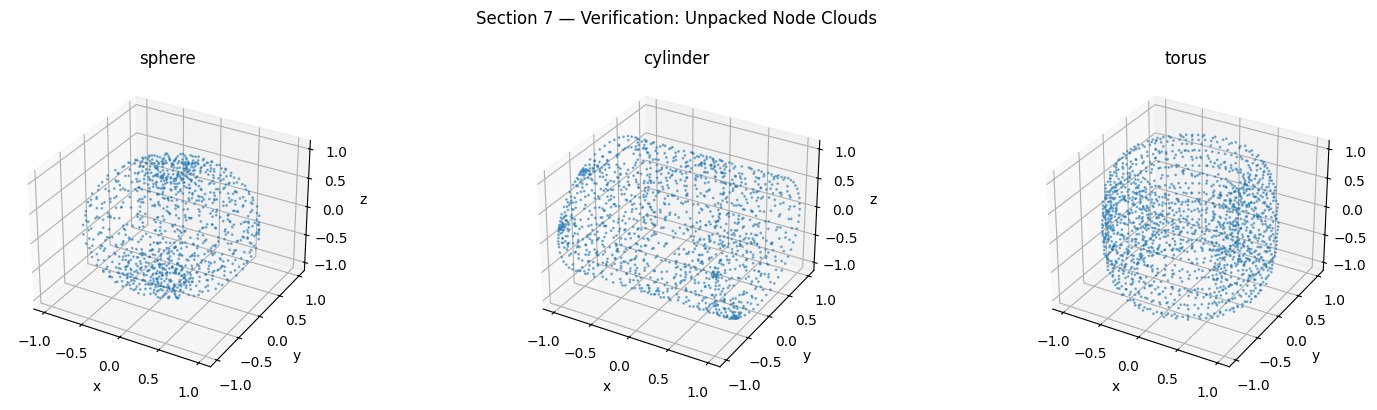

In [5]:

MAX_NODES  = 2048
GRID_H     = 32
GRID_W     = 64
N_CHANNELS = 3      # x, y, z

assert GRID_H * GRID_W == MAX_NODES

# 7.2 — Normalization: scale each mesh to [-1, 1]
# Must match tanh output range of the generator
def normalize_nodes(nodes):
    mins   = nodes.min(axis=0)
    maxs   = nodes.max(axis=0)
    ranges = maxs - mins
    ranges[ranges < 1e-8] = 1.0
    return (2.0 * (nodes - mins) / ranges - 1.0).astype(np.float32)

# 7.3 — Pack (N,3) array into fixed (3,H,W) matrix + mask
def pack_nodes_to_matrix(nodes, grid_h=GRID_H, grid_w=GRID_W):
    mat  = np.zeros((3, grid_h, grid_w), dtype=np.float32)
    mask = np.zeros((1, grid_h, grid_w), dtype=np.float32)

    n_fit = min(len(nodes), grid_h * grid_w)

    for ch, axis in enumerate([0, 1, 2]):
        flat         = mat[ch].ravel()
        flat[:n_fit] = nodes[:n_fit, axis]
        mat[ch]      = flat.reshape(grid_h, grid_w)

    mask_flat         = mask[0].ravel()
    mask_flat[:n_fit] = 1.0
    mask[0]           = mask_flat.reshape(grid_h, grid_w)

    return mat, mask

# 7.4 — Process all raw samples
processed = []

for sample in raw_dataset:
    nodes_norm    = normalize_nodes(sample['nodes'])
    mat, mask     = pack_nodes_to_matrix(nodes_norm)

    processed.append({
        'matrix'  : mat,
        'mask'    : mask,
        'label'   : sample['label'],
        'geometry': sample['geometry'],
    })

print(f"Processed {len(processed)} samples")
print(f"Matrix shape : {processed[0]['matrix'].shape}")
print(f"Mask shape   : {processed[0]['mask'].shape}")

# 7.5 — PyTorch Dataset
class MeshDataset(Dataset):
    def __init__(self, processed_list):
        self.data = processed_list

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        return (
            torch.tensor(item['matrix'], dtype=torch.float32),
            torch.tensor(item['mask'],   dtype=torch.float32),
            torch.tensor(item['label'],  dtype=torch.long),
        )

mesh_dataset = MeshDataset(processed)
dataloader   = DataLoader(mesh_dataset, batch_size=3, shuffle=True)

print(f"\nDataLoader ready")
print(f"  Batches per epoch : {len(dataloader)}")
print(f"  Batch contents    : (matrix, mask, label)")

# 7.6 — Visual verification
def unpack_matrix_to_nodes(mat, mask):
    x = mat[0].ravel()
    y = mat[1].ravel()
    z = mat[2].ravel()
    m = mask[0].ravel().astype(bool)
    return np.stack([x[m], y[m], z[m]], axis=1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4),
                         subplot_kw={'projection': '3d'})

for i, geom_name in enumerate(GEOMETRY_LABEL.keys()):
    sample = next(p for p in processed if p['geometry'] == geom_name)
    nodes  = unpack_matrix_to_nodes(sample['matrix'], sample['mask'])
    axes[i].scatter(nodes[:,0], nodes[:,1], nodes[:,2], s=1, alpha=0.5)
    axes[i].set_title(geom_name)
    axes[i].set_xlabel('x')
    axes[i].set_ylabel('y')
    axes[i].set_zlabel('z')

plt.suptitle("Section 7 — Verification: Unpacked Node Clouds")
plt.tight_layout()
plt.show()

In [6]:
N_CLASSES    = 3     # sphere, cylinder, torus
INIT_FILTERS = 256
INIT_H       = 2     # 2 × 16 = 32 = GRID_H  ✓
INIT_W       = 4     # 4 × 16 = 64 = GRID_W  ✓

assert INIT_H * 16 == GRID_H
assert INIT_W * 16 == GRID_W
print(f"Generator upsamples: ({INIT_H},{INIT_W}) → ({GRID_H},{GRID_W})")

# 8.2 — Single upsampling block
# Doubles H and W, halves filters
class GeneratorBlock(nn.Module):
    def __init__(self, in_filters, out_filters):
        super().__init__()
        self.block = nn.Sequential(
            nn.ConvTranspose2d(in_filters, out_filters,
                               kernel_size=4, stride=2,
                               padding=1, bias=False),
            nn.BatchNorm2d(out_filters),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

class GeneratorV3(nn.Module):
    def __init__(self):
        super().__init__()

        # Deeper template — more capacity per geometry
        # 512 filters instead of 256
        self.geometry_templates = nn.Embedding(
            N_CLASSES,
            512 * INIT_H * INIT_W    # bigger starting template
        )

        # Extra FC layers to transform template
        # before upsampling — gives network more
        # freedom to reshape the template
        self.template_fc = nn.Sequential(
            nn.Linear(512 * INIT_H * INIT_W,
                      512 * INIT_H * INIT_W),
            nn.LayerNorm(512 * INIT_H * INIT_W),
            nn.ReLU(inplace=True),
            nn.Linear(512 * INIT_H * INIT_W,
                      512 * INIT_H * INIT_W),
            nn.LayerNorm(512 * INIT_H * INIT_W),
            nn.ReLU(inplace=True),
        )

        # 4 upsampling blocks instead of 3
        # more capacity to learn fine details
        # (2,4)→(4,8)→(8,16)→(16,32)→(32,64)
        self.deconv_blocks = nn.Sequential(
            GeneratorBlock(512, 256),
            GeneratorBlock(256, 128),
            GeneratorBlock(128, 64),
            GeneratorBlock(64, 32),
        )

        self.output_layer = nn.Sequential(
            nn.Conv2d(32, 3,
                      kernel_size=3,
                      padding=1,
                      bias=False),
            nn.Tanh()
        )

    def forward(self, labels):
        x = self.geometry_templates(labels)
        # shape: (B, 512*2*4) = (B, 4096)

        x = self.template_fc(x)
        # deeper transformation before upsampling

        x = x.view(-1, 512, INIT_H, INIT_W)
        # shape: (B, 512, 2, 4)

        x = self.deconv_blocks(x)
        # shape: (B, 32, 32, 64)

        x = self.output_layer(x)
        # shape: (B, 3, 32, 64)

        return x


# Build V3
G = GeneratorV3().to(device)

# Verify
dummy_labels = torch.randint(0, N_CLASSES, (4,)).to(device)
dummy_out    = G(dummy_labels)
print(f"Output shape : {dummy_out.shape}")
print(f"Shape match  : {dummy_out.shape == (4, 3, GRID_H, GRID_W)}")
print(f"Output range : [{dummy_out.min():.3f}, {dummy_out.max():.3f}]")
total_params = sum(p.numel() for p in G.parameters()
                   if p.requires_grad)
print(f"Total params : {total_params:,}")

Generator upsamples: (2,4) → (32,64)
Output shape : torch.Size([4, 3, 32, 64])
Shape match  : True
Output range : [-0.922, 0.951]
Total params : 36,378,400


Starting training...
  Samples       : 35
  Batch size    : 3
  Batches/epoch : 12
  Max epochs    : 500
  Stop loss     : 0.02
  Device        : cuda

Epoch [  50/500] | Loss: 0.247323 | Best: 0.244884
Epoch [ 100/500] | Loss: 0.245145 | Best: 0.243622
Epoch [ 150/500] | Loss: 0.246871 | Best: 0.243200
Epoch [ 200/500] | Loss: 0.244054 | Best: 0.243019
Epoch [ 250/500] | Loss: 0.242816 | Best: 0.241600
Epoch [ 300/500] | Loss: 0.242559 | Best: 0.240678
Epoch [ 350/500] | Loss: 0.242100 | Best: 0.240455
Epoch [ 400/500] | Loss: 0.242025 | Best: 0.239981
Epoch [ 450/500] | Loss: 0.242341 | Best: 0.239981
Epoch [ 500/500] | Loss: 0.240899 | Best: 0.239981

Training complete.
  Final loss : 0.240899
  Best loss  : 0.239981
  Model saved: best_generator.pth


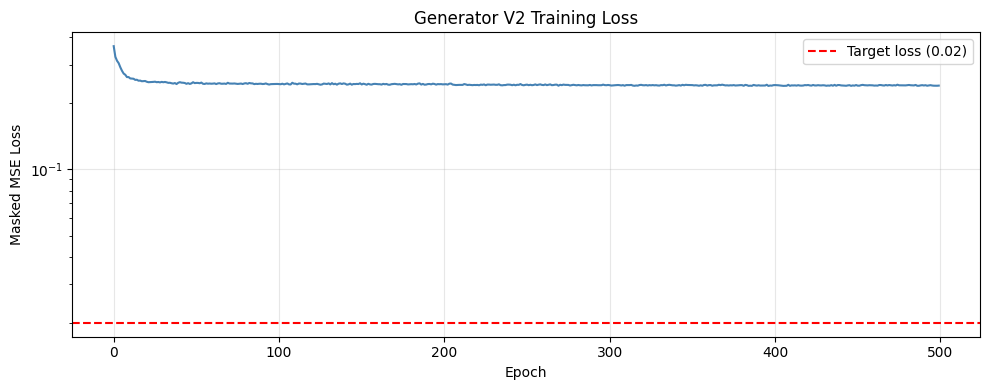

Best model weights loaded — ready for Section 10


In [7]:
# 9.1 — Hyperparameters
LEARNING_RATE =0.0005    # higher lr works well without noise variance
EPOCHS        = 500
STOP_LOSS     = 0.02
BETA1         = 0.9      # standard Adam betas (not DCGAN betas,
BETA2         = 0.999    # since we removed adversarial training)

# 9.2 — Optimizer + scheduler
optimizer = optim.Adam(G.parameters(),
                       lr=LEARNING_RATE,
                       betas=(BETA1, BETA2))

# Reduces lr by half if loss doesn't improve for 50 epochs
# prevents getting stuck at a plateau
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    patience=30,
    factor=0.5
)

# 9.3 — Masked MSE loss
# Only computes loss over real node positions, not padding
mse_loss = nn.MSELoss(reduction='sum')

def masked_mse_loss(pred, target, mask):
    mask_expanded = mask.expand_as(pred)
    pred_masked   = pred   * mask_expanded
    target_masked = target * mask_expanded
    loss          = mse_loss(pred_masked, target_masked)
    n_real_cells  = mask_expanded.sum()
    if n_real_cells > 0:
        loss = loss / n_real_cells
    return loss

# 9.4 — Training loop
G.train()
loss_history = []
best_loss    = float('inf')

print("Starting training...")
print(f"  Samples       : {len(mesh_dataset)}")
print(f"  Batch size    : 3")
print(f"  Batches/epoch : {len(dataloader)}")
print(f"  Max epochs    : {EPOCHS}")
print(f"  Stop loss     : {STOP_LOSS}")
print(f"  Device        : {device}\n")

for epoch in range(EPOCHS):
    epoch_loss = 0.0

    for matrices, masks, labels in dataloader:
        matrices = matrices.to(device)   # (B, 3, 32, 64)
        masks    = masks.to(device)      # (B, 1, 32, 64)
        labels   = labels.to(device)     # (B,)

        # Forward pass — V2 takes only labels, no noise
        pred = G(labels)

        # Masked loss
        loss = masked_mse_loss(pred, matrices, masks)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(G.parameters(), 1.0)
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(dataloader)
    loss_history.append(avg_loss)
    scheduler.step(avg_loss)

    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch+1:4d}/{EPOCHS}] | "
              f"Loss: {avg_loss:.6f} | "
              f"Best: {best_loss:.6f}")

    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(G.state_dict(), 'best_generator.pth')

    if avg_loss <= STOP_LOSS:
        print(f"\nConverged at epoch {epoch+1} "
              f"with loss {avg_loss:.6f}")
        break

print(f"\nTraining complete.")
print(f"  Final loss : {avg_loss:.6f}")
print(f"  Best loss  : {best_loss:.6f}")
print(f"  Model saved: best_generator.pth")

# 9.5 — Loss curve
plt.figure(figsize=(10, 4))
plt.plot(loss_history, color='steelblue', linewidth=1.5)
plt.axhline(y=STOP_LOSS, color='red', linestyle='--', label=f'Target loss ({STOP_LOSS})')
plt.xlabel('Epoch')
plt.ylabel('Masked MSE Loss')
plt.title('Generator V2 Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.tight_layout()
plt.show()

# 9.6 — Load best weights
G.load_state_dict(torch.load('best_generator.pth'))
G.eval()
print("Best model weights loaded — ready for Section 10")

Reference for sphere: 1170 nodes
Reference for cylinder: 1366 nodes
Reference for torus: 1584 nodes

GENERATING MESHES FOR ALL GEOMETRIES

── SPHERE ──
  sphere: generated 2048 nodes
  Triangulation: 13279 elements
  Triangulation: 5831 elements

  Quality Report — sphere (TetGen):
    Total elements : 5794
    Mean quality   : 0.952
    q >= 0.9       : 89.7%
    q >= 0.5       : 99.6%
    q <  0.5       : 0.4%  ← poor elements


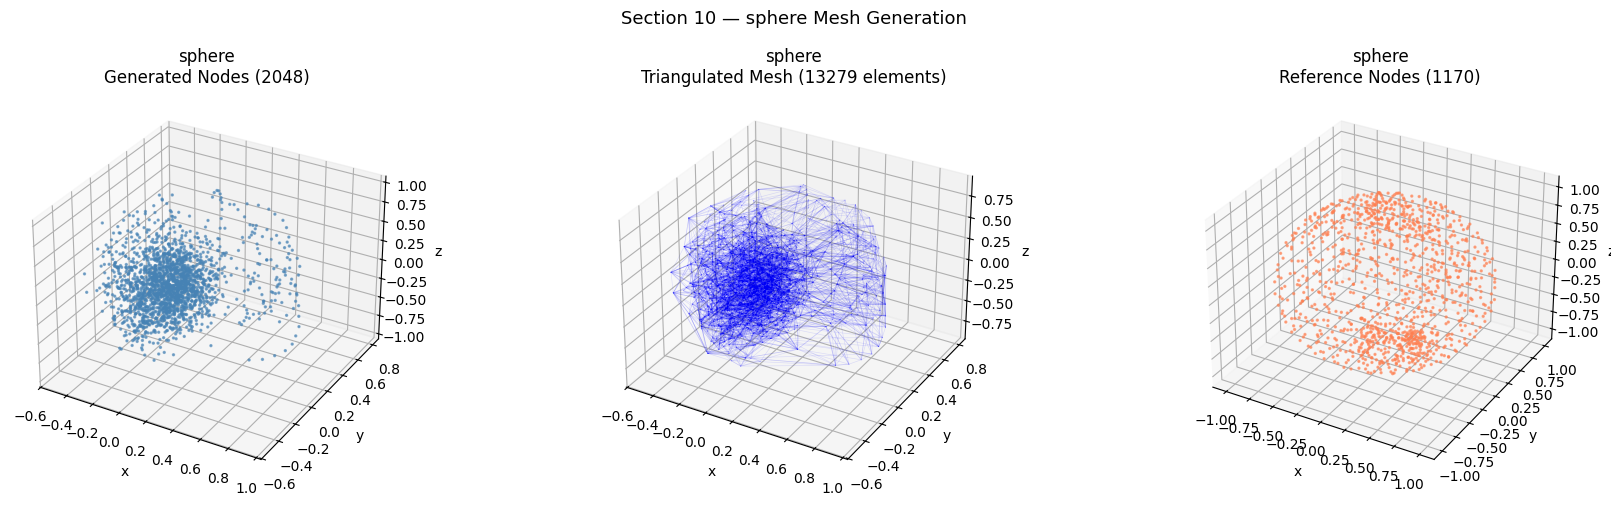


  Quality Report — sphere (Generated):
    Total elements : 13279
    Mean quality   : 0.891
    q >= 0.9       : 58.4%
    q >= 0.5       : 99.3%
    q <  0.5       : 0.7%  ← poor elements


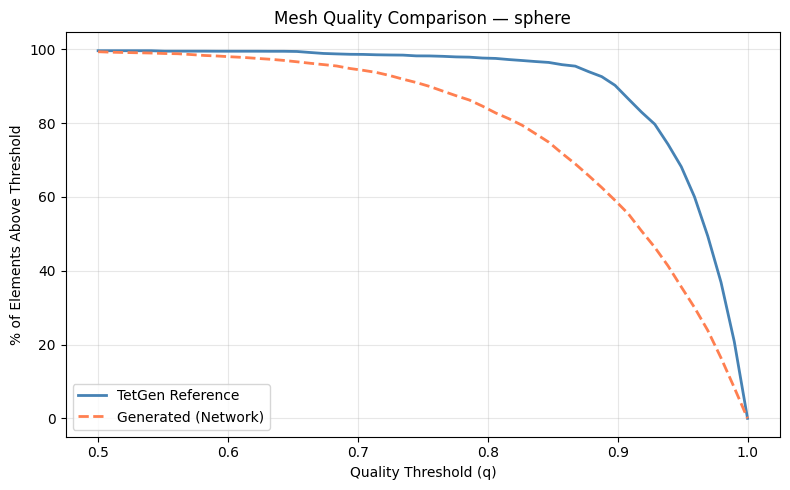


── CYLINDER ──
  cylinder: generated 2048 nodes
  Triangulation: 13511 elements
  Triangulation: 6328 elements

  Quality Report — cylinder (TetGen):
    Total elements : 6322
    Mean quality   : 0.944
    q >= 0.9       : 88.9%
    q >= 0.5       : 98.4%
    q <  0.5       : 1.6%  ← poor elements


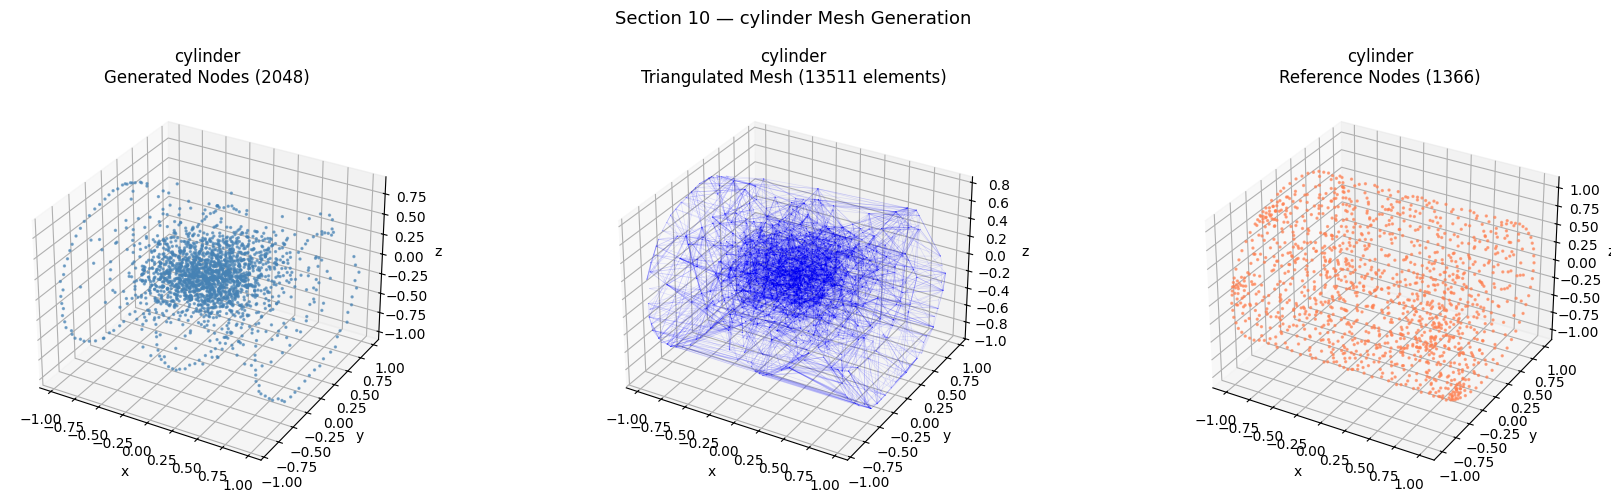


  Quality Report — cylinder (Generated):
    Total elements : 13511
    Mean quality   : 0.877
    q >= 0.9       : 55.4%
    q >= 0.5       : 98.3%
    q <  0.5       : 1.7%  ← poor elements


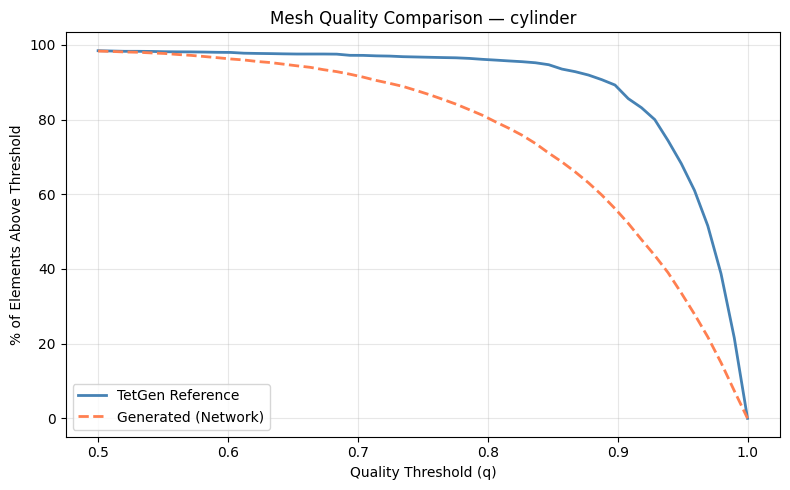


── TORUS ──
  torus: generated 2048 nodes
  Triangulation: 13328 elements
  Triangulation: 9508 elements

  Quality Report — torus (TetGen):
    Total elements : 9367
    Mean quality   : 0.863
    q >= 0.9       : 49.2%
    q >= 0.5       : 98.0%
    q <  0.5       : 2.0%  ← poor elements


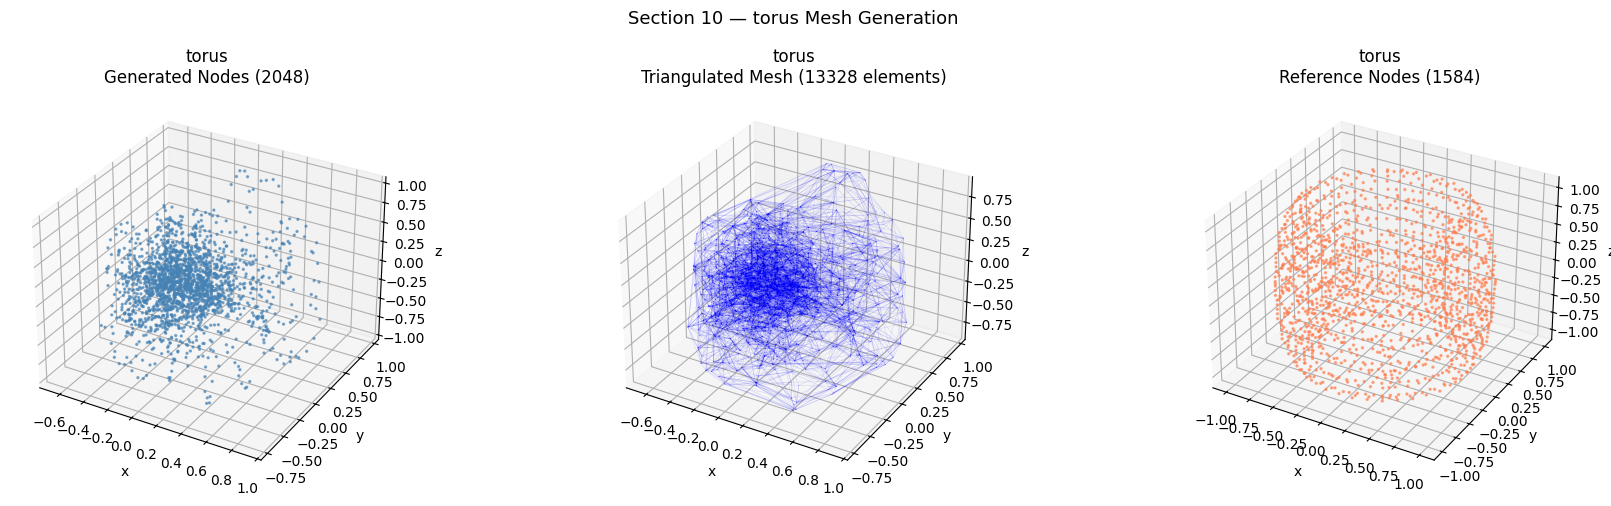


  Quality Report — torus (Generated):
    Total elements : 13328
    Mean quality   : 0.887
    q >= 0.9       : 57.2%
    q >= 0.5       : 99.1%
    q <  0.5       : 0.9%  ← poor elements


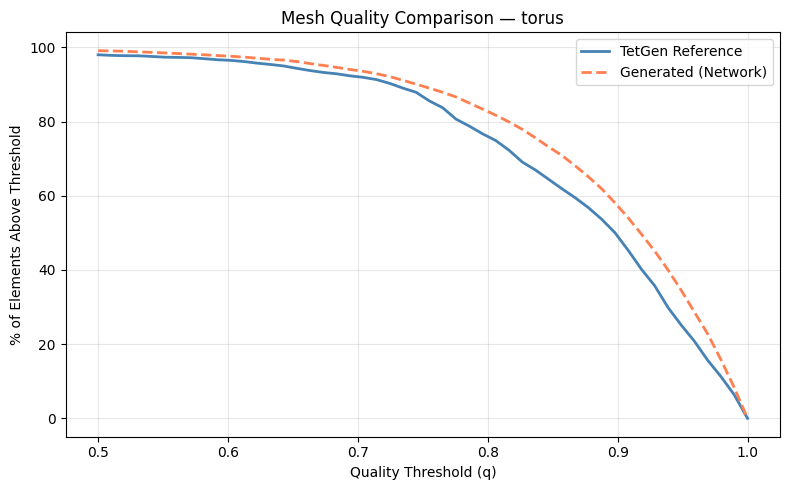


FINAL QUALITY SUMMARY
Geometry       Elements   Mean q   q>=0.9   q>=0.5
--------------------------------------------------
sphere            13279    0.891    58.4%    99.3%
cylinder          13511    0.877    55.4%    98.3%
torus             13328    0.887    57.2%    99.1%


In [8]:
import numpy as np

from scipy.spatial import Delaunay
import pyvista as pv

# ── 10.1  Generate node coordinates from trained network ─────
# For each geometry, pass its label through the trained
# generator and unpack the output matrix to node coordinates

def generate_nodes(label, geometry_name):
    """
    Uses trained generator to produce node coordinates
    for a given geometry label.

    label         : int   e.g. 0=sphere, 1=cylinder, 2=torus
    geometry_name : str   just for printing

    returns nodes : np.ndarray (N, 3)  in normalized [-1,1] space
    """
    G.eval()
    with torch.no_grad():
        label_tensor = torch.tensor(
            [label], dtype=torch.long
        ).to(device)

        # Forward pass — get (1, 3, 32, 64) output
        output = G(label_tensor)

        # Move to CPU and remove batch dimension
        output = output.squeeze(0).cpu().numpy()
        # shape: (3, 32, 64)

    # Unpack matrix to node coordinates
    # using the same function from Section 7
    # We need a mask — use threshold on coordinate magnitude
    x = output[0].ravel()   # x coordinates
    y = output[1].ravel()   # y coordinates
    z = output[2].ravel()   # z coordinates

    # Filter out near-zero padding cells
    # real nodes have meaningful coordinates
    # padding cells are all exactly 0.0
    coords = np.stack([x, y, z], axis=1)
    magnitudes = np.abs(coords).sum(axis=1)
    real_mask = magnitudes > 1e-6  # Lowered threshold for real nodes
    nodes = coords[real_mask]

    print(f"  {geometry_name}: generated {len(nodes)} nodes")
    return nodes


# ── 10.2  Delaunay Triangulation ─────────────────────────────
# Same as what the paper describes — take generated node
# coordinates and triangulate over them to get the final mesh
# This gives us the connectivity matrix (which nodes
# connect to form each tetrahedron/triangle)

def triangulate_nodes(nodes):
    """
    Runs Delaunay triangulation over generated node coordinates.

    nodes   : np.ndarray (N, 3)
    returns : scipy Delaunay object containing connectivity
    """
    tri = Delaunay(nodes)
    print(f"  Triangulation: {len(tri.simplices)} elements")
    return tri


# ── 10.3  Visualize generated mesh ───────────────────────────
# Plot the generated node cloud and triangulated mesh
# side by side for each geometry

def visualize_generated_mesh(nodes, tri, geometry_name,
                              ref_nodes=None):
    """
    Plots generated mesh alongside reference mesh for comparison.

    nodes         : generated node coordinates (N, 3)
    tri           : Delaunay triangulation object
    geometry_name : str
    ref_nodes     : reference TetGen nodes for comparison (optional)
    """
    n_plots = 3 if ref_nodes is not None else 2
    fig = plt.figure(figsize=(6 * n_plots, 5))

    # Plot 1 — Generated node cloud
    ax1 = fig.add_subplot(1, n_plots, 1, projection='3d')
    ax1.scatter(nodes[:,0], nodes[:,1], nodes[:,2],
                s=2, c='steelblue', alpha=0.6)
    ax1.set_title(f'{geometry_name}\nGenerated Nodes ({len(nodes)})')
    ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('z')

    # Plot 2 — Triangulated mesh (show simplex edges)
    ax2 = fig.add_subplot(1, n_plots, 2, projection='3d')
    # Plot a subset of simplices to avoid overcrowding
    for simplex in tri.simplices[::5]:   # every 5th simplex
        pts = nodes[simplex]
        # Draw edges of each tetrahedron
        for i in range(4):
            for j in range(i+1, 4):
                ax2.plot([pts[i,0], pts[j,0]],
                         [pts[i,1], pts[j,1]],
                         [pts[i,2], pts[j,2]],
                         'b-', alpha=0.1, linewidth=0.5)
    ax2.set_title(f'{geometry_name}\nTriangulated Mesh ({len(tri.simplices)} elements)')
    ax2.set_xlabel('x'); ax2.set_ylabel('y'); ax2.set_zlabel('z')

    # Plot 3 — Reference mesh nodes (if provided)
    if ref_nodes is not None:
        ax3 = fig.add_subplot(1, n_plots, 3, projection='3d')
        ax3.scatter(ref_nodes[:,0], ref_nodes[:,1], ref_nodes[:,2],
                    s=2, c='coral', alpha=0.6)
        ax3.set_title(f'{geometry_name}\nReference Nodes ({len(ref_nodes)})')
        ax3.set_xlabel('x'); ax3.set_ylabel('y'); ax3.set_zlabel('z')

    plt.suptitle(f'Section 10 — {geometry_name} Mesh Generation',
                 fontsize=13)
    plt.tight_layout()
    plt.show()


# ── 10.4  Field's Quality Metric ─────────────────────────────
# From the paper (equation 3):
# q = (b+c-a)(c+a-b)(a+b-c) / abc
# where a, b, c are edge lengths of a triangle
#
# q = 1.0  → perfect equilateral triangle
# q >= 0.9 → excellent quality
# q >= 0.5 → acceptable quality
# q < 0.5  → poor quality, may cause simulation errors

def triangle_quality(a, b, c):
    """Field's quality metric for triangle with edge lengths a,b,c."""
    num = (b+c-a) * (c+a-b) * (a+b-c)
    den = a * b * c
    if den < 1e-12 or num <= 0:
        return 0.0
    return (num / den) ** (1/3)

def evaluate_mesh_quality(nodes, tri, label):
    """
    Computes Field's quality metric for all triangles in mesh.
    Uses first 3 nodes of each simplex (tetrahedron face).

    nodes : np.ndarray (N, 3)
    tri   : Delaunay triangulation
    label : str  geometry name for printing
    """
    qualities = []

    for simplex in tri.simplices:
        # Use first 3 nodes of each simplex
        # to form a triangle for quality evaluation
        pts = nodes[simplex[:3]]

        a = np.linalg.norm(pts[1] - pts[0])
        b = np.linalg.norm(pts[2] - pts[1])
        c = np.linalg.norm(pts[0] - pts[2])

        q = triangle_quality(a, b, c)
        if q > 0:
            qualities.append(q)

    qualities = np.array(qualities)

    print(f"\n  Quality Report — {label}:")
    print(f"    Total elements : {len(qualities)}")
    print(f"    Mean quality   : {qualities.mean():.3f}")
    print(f"    q >= 0.9       : {(qualities>=0.9).mean()*100:.1f}%")
    print(f"    q >= 0.5       : {(qualities>=0.5).mean()*100:.1f}%")
    print(f"    q <  0.5       : {(qualities<0.5).mean()*100:.1f}%  ← poor elements")

    return qualities


# ── 10.5  Quality comparison plot ────────────────────────────
# Recreates Figure 6a from the paper —
# percentage of mesh triangles above quality threshold

def plot_quality_comparison(gen_qualities, ref_qualities,
                             geometry_name):
    """
    Plots quality distribution comparing generated mesh
    vs reference TetGen mesh — mirrors paper's Figure 6a.
    """
    thresholds = np.linspace(0.5, 1.0, 50)

    gen_pct = [(gen_qualities >= t).mean() * 100
               for t in thresholds]
    ref_pct = [(ref_qualities >= t).mean() * 100
               for t in thresholds]

    plt.figure(figsize=(8, 5))
    plt.plot(thresholds, ref_pct,
             label='TetGen Reference', color='steelblue',
             linewidth=2)
    plt.plot(thresholds, gen_pct,
             label='Generated (Network)', color='coral',
             linewidth=2, linestyle='--')
    plt.xlabel('Quality Threshold (q)')
    plt.ylabel('% of Elements Above Threshold')
    plt.title(f'Mesh Quality Comparison — {geometry_name}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# ── 10.6  Run everything for all geometries ──────────────────

# Get one reference mesh per geometry from training data
# for comparison — use the middle density (minratio=1.8)
reference_samples = {}
for geom_name in GEOMETRY_LABEL.keys():
    # Find a sample with ~1000-1500 nodes for clean comparison
    candidates = [s for s in raw_dataset
                  if s['geometry'] == geom_name
                  and 800 <= s['n_nodes'] <= 1600]
    if candidates:
        # Pick the one closest to 1200 nodes
        ref = min(candidates,
                  key=lambda s: abs(s['n_nodes'] - 1200))
        reference_samples[geom_name] = ref
        print(f"Reference for {geom_name}: {ref['n_nodes']} nodes")

print("\n" + "="*50)
print("GENERATING MESHES FOR ALL GEOMETRIES")
print("="*50)

all_qualities = {}   # store for final summary

for geom_name, label in GEOMETRY_LABEL.items():
    print(f"\n── {geom_name.upper()} ──")

    # Step 1 — Generate nodes
    gen_nodes = generate_nodes(label, geom_name)

    # Step 2 — Triangulate
    gen_tri = triangulate_nodes(gen_nodes)

    # Step 3 — Get reference nodes
    ref_nodes = None
    ref_qualities = None
    if geom_name in reference_samples:
        ref_raw   = reference_samples[geom_name]['nodes']
        ref_norm  = normalize_nodes(ref_raw)
        ref_tri   = triangulate_nodes(ref_norm)
        ref_nodes = ref_norm
        ref_qualities = evaluate_mesh_quality(
            ref_norm, ref_tri, f"{geom_name} (TetGen)"
        )

    # Step 4 — Visualize
    visualize_generated_mesh(gen_nodes, gen_tri,
                             geom_name, ref_nodes)

    # Step 5 — Evaluate quality
    gen_qualities = evaluate_mesh_quality(
        gen_nodes, gen_tri, f"{geom_name} (Generated)"
    )
    all_qualities[geom_name] = gen_qualities

    # Step 6 — Compare quality plots
    if ref_qualities is not None:
        plot_quality_comparison(gen_qualities, ref_qualities,
                                geom_name)


# ── 10.7  Final Summary ───────────────────────────────────────
print("\n" + "="*50)
print("FINAL QUALITY SUMMARY")
print("="*50)
print(f"{'Geometry':<12} {'Elements':>10} {'Mean q':>8} "
      f"{'q>=0.9':>8} {'q>=0.5':>8}")
print("-" * 50)

for geom_name, qualities in all_qualities.items():
    print(f"{geom_name:<12} "
          f"{len(qualities):>10} "
          f"{qualities.mean():>8.3f} "
          f"{(qualities>=0.9).mean()*100:>7.1f}% "
          f"{(qualities>=0.5).mean()*100:>7.1f}%")

### Summary of Generated vs. Reference Mesh Properties

Let's provide a clear, tabular summary comparing the generated meshes with their TetGen references in terms of number of nodes and elements.

In [9]:
print("\n" + "="*70)
print("QUANTITATIVE MESH PROPERTY COMPARISON (Generated vs. TetGen)")
print("="*70)

print(f"{'Geometry':<12} | {'Type':<10} | {'Nodes':>8} | {'Elements':>10}")
print("-"*70)

for geom_name, label in GEOMETRY_LABEL.items():
    # Generated mesh properties
    gen_nodes_count = len(generate_nodes(label, geom_name))
    gen_tri = triangulate_nodes(generate_nodes(label, geom_name))
    gen_elements_count = len(gen_tri.simplices)
    print(f"{geom_name:<12} | {'Generated':<10} | {gen_nodes_count:>8} | {gen_elements_count:>10}")

    # Reference mesh properties (if available)
    if geom_name in reference_samples:
        ref_raw = reference_samples[geom_name]['nodes']
        ref_norm = normalize_nodes(ref_raw)
        ref_tri = triangulate_nodes(ref_norm)
        ref_nodes_count = len(ref_norm)
        ref_elements_count = len(ref_tri.simplices)
        print(f"{geom_name:<12} | {'TetGen':<10} | {ref_nodes_count:>8} | {ref_elements_count:>10}")
    else:
        print(f"{geom_name:<12} | {'TetGen':<10} | {'N/A':>8} | {'N/A':>10}")
    print("-"*70)


QUANTITATIVE MESH PROPERTY COMPARISON (Generated vs. TetGen)
Geometry     | Type       |    Nodes |   Elements
----------------------------------------------------------------------
  sphere: generated 2048 nodes
  sphere: generated 2048 nodes
  Triangulation: 13279 elements
sphere       | Generated  |     2048 |      13279
  Triangulation: 5831 elements
sphere       | TetGen     |     1170 |       5831
----------------------------------------------------------------------
  cylinder: generated 2048 nodes
  cylinder: generated 2048 nodes
  Triangulation: 13511 elements
cylinder     | Generated  |     2048 |      13511
  Triangulation: 6328 elements
cylinder     | TetGen     |     1366 |       6328
----------------------------------------------------------------------
  torus: generated 2048 nodes
  torus: generated 2048 nodes
  Triangulation: 13328 elements
torus        | Generated  |     2048 |      13328
  Triangulation: 9508 elements
torus        | TetGen     |     1584 |       950